In [1]:
import numpy as np
import pandas as pd

In [19]:
df = pd.read_csv(r"C:\Users\Urwashi\OneDrive\Desktop\netflix_titles.csv", encoding='ISO-8859-1')

In [9]:
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  ... Unnamed: 16  \
0  September 25, 2021          2020  PG-13     90 min  ...         NaN   
1  September 24, 2021          2021  TV-MA  2 Season

In [20]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
if df['rating'].isna().all():
    print("The 'rating' column contains no valid numeric data.")
    avg_rating=0
else:   
    avg_rating = np.nanmean(df['rating'])  # NumPy to calculate the mean, ignoring NaN
    df['rating'] = df['rating'].fillna(avg_rating)

print(df['rating'].head())

0    5.0
1    6.5
2    6.5
3    6.5
4    6.5
Name: rating, dtype: float64


In [3]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv(r"C:\Users\Urwashi\OneDrive\Desktop\netflix_titles.csv", encoding='ISO-8859-1')
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['release_year'] = pd.to_datetime(df['release_year'], format='%Y', errors='coerce')

In [6]:
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

  date_added release_year  rating   duration  \
0  25-Sep-21   2020-01-01     5.0     90 min   
1  24-Sep-21   2021-01-01     6.5  2 Seasons   
2  24-Sep-21   2021-01-01     6.5   1 Season   
3  24-Se

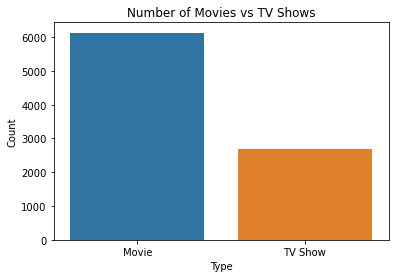

In [7]:
movie_vs_tv = df['type'].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=movie_vs_tv.index, y=movie_vs_tv.values)
plt.title('Number of Movies vs TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

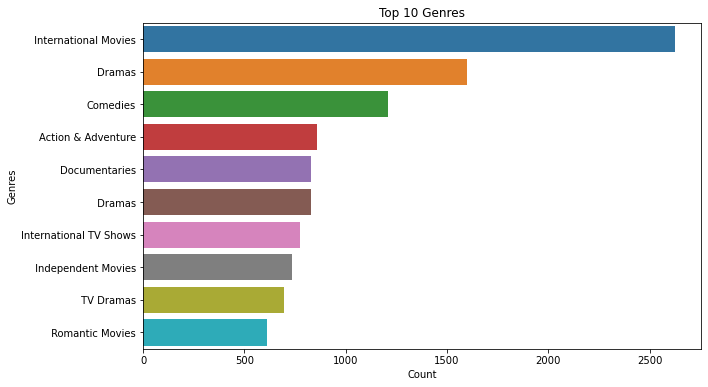

In [8]:
top_genres = df['listed_in'].str.split(',').explode().value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title('Top 10 Genres')
plt.xlabel('Count')
plt.ylabel('Genres')
plt.show()

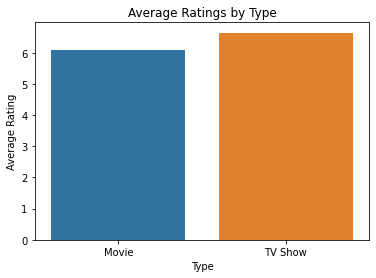

In [9]:
avg_ratings = df.groupby('type')['rating'].mean().reset_index()

plt.figure(figsize=(6, 4))
sns.barplot(x='type', y='rating', data=avg_ratings)
plt.title('Average Ratings by Type')
plt.xlabel('Type')
plt.ylabel('Average Rating')
plt.show()


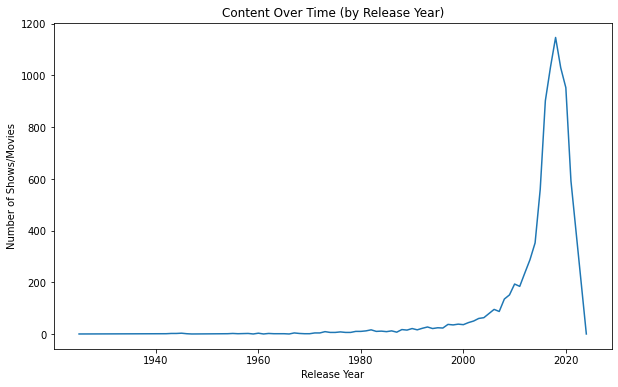

In [10]:
content_by_year = df.groupby(df['release_year'].dt.year)['show_id'].count().reset_index()
content_by_year.columns = ['release_year', 'count']

plt.figure(figsize=(10, 6))
sns.lineplot(x='release_year', y='count', data=content_by_year)
plt.title('Content Over Time (by Release Year)')
plt.xlabel('Release Year')
plt.ylabel('Number of Shows/Movies')
plt.show()

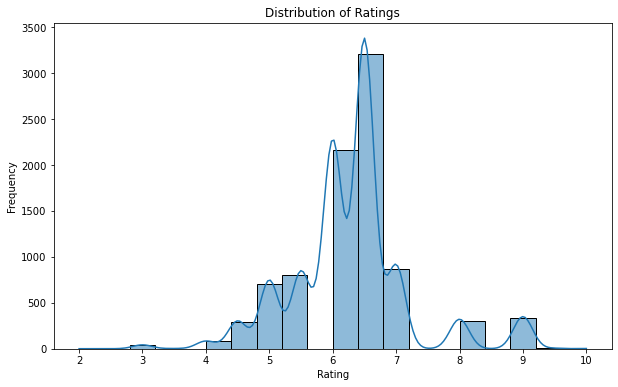

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df['rating'].dropna(), bins=20, kde=True)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

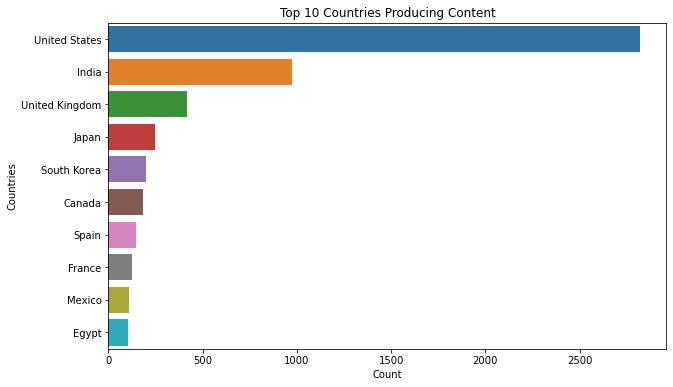

In [11]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title('Top 10 Countries Producing Content')
plt.xlabel('Count')
plt.ylabel('Countries')
plt.show()